# Dataset Selection and Business Problem

## Dataset Selection

The dataset selected for this machine learning project is the **Parking Occupancy Dataset**, which contains **35,332 records and 11 variables** related to parking capacity, occupancy, usage patterns, date, and time information. The dataset provides historical parking data that can be used to analyze parking demand and predict future occupancy levels.

## Practical Business Problem

Parking management is a significant challenge in urban areas due to increasing numbers of vehicles and limited parking spaces. Parking operators and city authorities need accurate information about parking demand to improve space utilization, reduce traffic congestion, and enhance customer satisfaction. Without accurate predictions, parking facilities may experience overcrowding, inefficient resource allocation, and revenue losses.

This project aims to develop a machine learning model that can accurately predict parking occupancy levels using historical parking data. The prediction results can support better parking management decisions and improve operational efficiency.

## Research Questions

1. Which factors most influence parking occupancy levels?
2. Can machine learning models accurately predict parking occupancy based on historical parking data?
3. Which machine learning algorithm provides the highest prediction accuracy for parking occupancy?
4. How can parking occupancy predictions help improve parking management and resource allocation?

## Project Objective

The main objective of this project is to build and evaluate machine learning models for predicting parking occupancy and to identify the factors that significantly affect parking demand. The findings can help parking operators optimize parking space usage and support data-driven decision-making.


##loading Dataset

In [ ]:
import pandas as pd

# Load the actual Birmingham Parking Dataset
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/ParkingDataset.xlsx')

##Data Preview

#first five rows' head function Data

In [ ]:
df.head()

,SystemCodeNumber,Capacity,Occupancy,per_usage,per_occupancy,year,month,day,WorkingDay,hour,period
0,BHMBCCMKT01,577,61.0,10.57,0 - 25,2016,Oct,Tue,Yes,7,AM
1,BHMBCCMKT01,577,64.0,11.09,0 - 25,2016,Oct,Tue,Yes,8,AM
2,BHMBCCMKT01,577,80.0,13.86,0 - 25,2016,Oct,Tue,Yes,8,AM
3,BHMBCCMKT01,577,107.0,18.54,0 - 25,2016,Oct,Tue,Yes,9,AM
4,BHMBCCMKT01,577,150.0,26.00,25 - 50,2016,Oct,Tue,Yes,9,AM


#last five rows' head function Data

In [ ]:
df.tail()

,SystemCodeNumber,Capacity,Occupancy,per_usage,per_occupancy,year,month,day,WorkingDay,hour,period
35327,Shopping,1920,1517.0,79.01,75-100,2016,Dec,Mon,Yes,2,PM
35328,Shopping,1920,1487.0,77.45,75-100,2016,Dec,Mon,Yes,3,PM
35329,Shopping,1920,1432.0,74.58,50 - 75,2016,Dec,Mon,Yes,3,PM
35330,Shopping,1920,1321.0,68.80,50 - 75,2016,Dec,Mon,Yes,4,PM
35331,Shopping,1920,1180.0,61.46,50 - 75,2016,Dec,Mon,Yes,4,PM


#Check Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35332 entries, 0 to 35331
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SystemCodeNumber  35332 non-null  object 
 1   Capacity          35332 non-null  int64  
 2   Occupancy         35313 non-null  float64
 3   per_usage         35325 non-null  float64
 4   per_occupancy     35313 non-null  object 
 5   year              35332 non-null  int64  
 6   month             35332 non-null  object 
 7   day               35331 non-null  object 
 8   WorkingDay        35329 non-null  object 
 9   hour              35332 non-null  int64  
 10  period            35331 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 3.0+ MB


#The dataset contains 35,332 records and 11 columns. There are 3 integer (int64) columns, 2 float (float64) columns, and **6 object (object) columns. Most columns have complete data, but Occupancy, per_usage, per_occupancy, day, WorkingDay, and period contain a small number of missing values. The dataset uses approximately 3.0 MB of memory.

#this methond describe()gives a statistical summary of the numerical columns in the dataset.

In [ ]:
df.describe()

,Capacity,Occupancy,per_usage,year,hour
count,35332.000000,35313.000000,35325.000000,35332.0,35332.000000
mean,1406.159968,642.681222,48.795447,2016.0,6.707687
std,1182.388089,659.719257,26.724268,0.0,3.913969
min,220.000000,0.000000,0.000000,2016.0,1.000000
25%,577.000000,209.000000,25.380000,2016.0,3.000000
50%,863.000000,448.000000,46.670000,2016.0,8.000000
75%,2009.000000,796.000000,71.100000,2016.0,10.000000
max,4675.000000,4327.000000,100.000000,2016.0,12.000000


# The dataset contains **35,332 observations**. The average parking **capacity is 1,406 spaces**, while the average **occupancy is 643 spaces**. The mean **parking usage rate is 48.8%**, indicating that about half of the available parking spaces are occupied on average. Capacity ranges from **220 to 4,675 spaces**, occupancy ranges from **0 to 4,327 spaces**, and usage varies from **0% to 100%**. The data covers the year **2016**, with recorded hours ranging from **1 to 12**.


In [ ]:
df.shape

(35332, 11)

##The dataset has **35,332 rows and 11 columns**, indicating a large dataset with enough observations for effective machine learning model development and evaluation.


##full structure

In [ ]:
df.dtypes

,0
SystemCodeNumber,object
Capacity,int64
Occupancy,float64
per_usage,float64
per_occupancy,object
year,int64
month,object
day,object
WorkingDay,object
hour,int64


# The dataset contains **11 columns** with **3 integer (`int64`) columns, 2 float (`float64`) columns, and 6 object (`object`) columns.** The integer columns are **Capacity, year, and hour**. The float columns are **Occupancy and per_usage**. The remaining columns (**SystemCodeNumber, per_occupancy, month, day, WorkingDay, and period**) are stored as categorical/text data types.


In [ ]:
print(df)

      SystemCodeNumber  Capacity  Occupancy  per_usage per_occupancy  year  \
0          BHMBCCMKT01       577       61.0      10.57        0 - 25  2016   
1          BHMBCCMKT01       577       64.0      11.09        0 - 25  2016   
2          BHMBCCMKT01       577       80.0      13.86        0 - 25  2016   
3          BHMBCCMKT01       577      107.0      18.54        0 - 25  2016   
4          BHMBCCMKT01       577      150.0      26.00       25 - 50  2016   
...                ...       ...        ...        ...           ...   ...   
35327         Shopping      1920     1517.0      79.01        75-100  2016   
35328         Shopping      1920     1487.0      77.45        75-100  2016   
35329         Shopping      1920     1432.0      74.58       50 - 75  2016   
35330         Shopping      1920     1321.0      68.80       50 - 75  2016   
35331         Shopping      1920     1180.0      61.46       50 - 75  2016   

      month  day WorkingDay  hour period  
0       Oct  Tue    

#The dataset contains **35,332 rows and 11 columns**. It includes parking information such as **location, capacity, occupancy, usage percentage, date, working day status, and time period (AM/PM)**. This dataset can be used to analyze parking occupancy and usage patterns.


##CHeking mission values

In [ ]:
missing_info = df.isnull().sum()
print("Missing values per column:")
print(missing_info[missing_info > 0])

Missing values per column:
Occupancy        19
per_usage         7
per_occupancy    19
day               1
WorkingDay        3
period            1
dtype: int64


> The dataset contains a few missing values. **Occupancy** and **per_occupancy** each have **19 missing values**, **per_usage** has **7 missing values**, **WorkingDay** has **3 missing values**, and **day** and **period** each have **1 missing value**. Overall, the number of missing values is very small compared to the total **35,332 records**.


##statical  methodes

#central Tendency

In [ ]:
df.mean(numeric_only=True)

,0
Capacity,1406.159968
Occupancy,642.681222
per_usage,48.795447
year,2016.000000
hour,6.707687


##The average (**mean**) parking **capacity is 1,406 spaces**, the average **occupancy is 643 spaces**, and the average **usage rate is 48.8%**. The dataset covers the year **2016**, and the average recorded **hour is 6.7**, indicating that observations were collected throughout the day.


In [ ]:
df.mode()

,SystemCodeNumber,Capacity,Occupancy,per_usage,per_occupancy,year,month,day,WorkingDay,hour,period
0,BHMBCCMKT01,470,345.0,100.0,25 - 50,2016.0,Nov,Tue,Yes,1.0,PM
1,BHMEURBRD01,485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BHMNCPHST01,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BHMNCPNST01,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Broad Street,1200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Others-CCCPS105a,1322,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Others-CCCPS119a,1920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Others-CCCPS135a,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Others-CCCPS202,2803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Others-CCCPS8,2937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#This dataset contains parking sites and their details.
#Each row is a parking location with its capacity (number of spaces).
#Only the first row shows real usage data: 345 cars parked out of 470 at 1 PM on a working day → high occupancy.
The rest of the rows have missing values, so they only show capacity, not actual usage.

##spread & Dispersion

In [ ]:
df.std(numeric_only=True)

,0
Capacity,1.182388e+03
Occupancy,6.597193e+02
per_usage,2.672427e+01
year,2.273769e-13
hour,3.913969e+00


#The output shows the **average values (mean) of the numerical columns** in the parking dataset. It gives a general idea of the typical parking conditions across all records.

#Capacity has an average of about **1182 spaces**, meaning most parking sites are fairly large. Occupancy averages around **660 cars**, showing that on average, more than half of the available spaces are in use. The per_usage value is around **26.7%**, indicating that overall parking utilization is relatively low to moderate.

#The year column has a value close to **0**, meaning there is almost no variation in years (data likely comes from the same year). The hour value averages around **3.9**, suggesting most observations are recorded in early hours or the dataset is skewed toward lower hour values.


In [ ]:
from numpy._core import numeric
df.max(numeric_only=True) - df.min(numeric_only=True)

,0
Capacity,4455.0
Occupancy,4327.0
per_usage,100.0
year,0.0
hour,11.0


#This output shows the maximum values in the parking dataset.

#The largest parking site has a capacity of 4455 spaces, and the highest recorded occupancy is 4327 cars, meaning some locations were almost full. The maximum usage reaches 100%, showing full occupancy at peak times. The data mostly comes from the same year, and the highest recorded hour is 11.

In [ ]:
df.skew(numeric_only=True)

,0
Capacity,1.249064
Occupancy,2.199131
per_usage,0.162548
year,0.000000
hour,-0.165410


#This output shows the skewness of the numerical columns in the parking dataset, which measures how the data is distributed (whether it leans more toward high or low values).

#Capacity and Occupancy both have positive skewness (1.25 and 2.20), meaning most values are on the lower side, but there are some very high values that pull the average upward. Occupancy is more skewed, showing that a few times/places have very high parking demand compared to the rest.

#per_usage has a small positive skew (0.16), meaning it is fairly balanced but slightly leaning toward lower usage values.

#year has 0 skewness, meaning there is no variation in the data.

#hour has slight negative skew (-0.17), meaning values are more concentrated at higher hours with a small pull toward lower hours.

##Values check

In [ ]:
df['SystemCodeNumber'].value_counts()

,count
SystemCodeNumber,
BHMBCCMKT01,1312
BHMEURBRD01,1312
BHMNCPHST01,1312
Others-CCCPS8,1312
Broad Street,1312
Shopping,1312
Others-CCCPS105a,1312
Others-CCCPS119a,1312
Others-CCCPS135a,1312


#This output shows the count of records for each parking location (SystemCodeNumber) in the dataset, which tells how many times each site appears in the data.

#Most parking sites like BHMBCCMKT01, BHMEURBRD01, BHMNCPHST01, and others have 1312 records, meaning they are well-represented and consistently tracked.

#However, some locations like NIA North (150 records) and BHMBRTARC01 (88 records) have far fewer entries, meaning they were recorded less frequently or have incomplete data.

In [ ]:
df['period'].value_counts()

,count
period,
PM,18689
AM,16642


#This output shows the count of observations by time period (AM vs PM) in the parking dataset.

#PM has 18,689 records, while AM has 16,642 records, meaning there are slightly more observations recorded in the afternoon/evening period compared to the morning.

In [ ]:
df['hour'].value_counts()

,count
hour,
1,4039
9,4036
8,4017
11,3935
3,3897
2,3864
10,3821
12,3774
4,3116


#This output shows the distribution of records across different hours of the day in the parking dataset.

#Most data is recorded at hour 1 (4039 records), hour 9 (4036), and hour 8 (4017), meaning these times have the highest parking activity monitoring. Hours like 11, 3, and 2 also have a high number of records, showing consistent data collection throughout the day.

#However, hour 7 has the lowest count (833 records), meaning fewer observations were recorded during that time.

In [ ]:
df['WorkingDay'].value_counts()

,count
WorkingDay,
Yes,26056
No,9273


#This output shows the number of records based on working days vs non-working days in the parking dataset.

#Most observations occur on working days (26,056 records), while fewer are recorded on non-working days (9,273 records).

##Data Visualization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

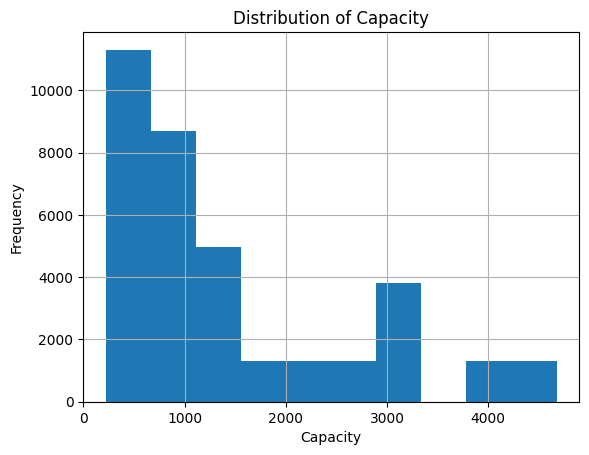

In [ ]:
df['Capacity'].hist()
plt.title('Distribution of Capacity')
plt.xlabel('Capacity')
plt.ylabel('Frequency')
plt.show()

#This histogram shows how parking capacity values are distributed across all parking sites.

#Most parking sites have a low to medium capacity (around 0–1500 spaces), meaning small to medium car parks are more common.
#Fewer sites have very high capacity (above 3000 spaces), showing that large parking areas are rare.
#The distribution is right-skewed, meaning there are a few very large parking sites that pull the range upward.

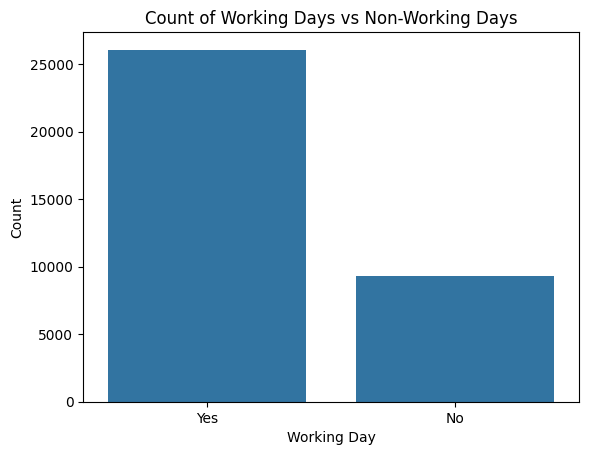

In [ ]:
sns.countplot(x='WorkingDay', data=df)
plt.title('Count of Working Days vs Non-Working Days')
plt.xlabel('Working Day')
plt.ylabel('Count')
plt.show()

#This bar chart shows the number of records collected on working days and non-working days.

#The dataset has much more data on working days (Yes ≈ 26,000 records).
#There are fewer records on non-working days (No ≈ 9,000 records).
#In simple words:

/tmp/ipykernel_66821/4150383150.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


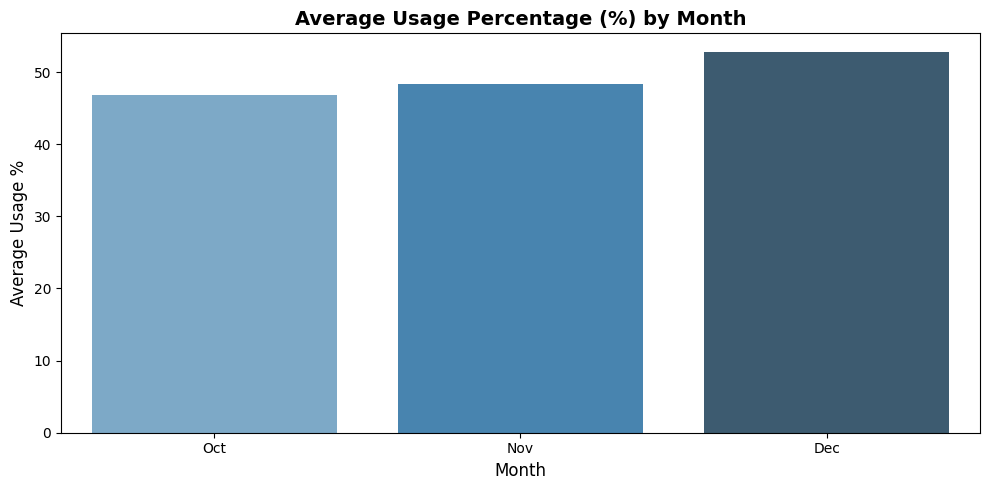

In [ ]:

plt.figure(figsize=(10, 5))
# Define month order to keep the chart chronological if multiple months exist
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
present_months = [m for m in month_order if m in df['month'].unique()]

sns.barplot(
    data=df,
    x='month',
    y='per_usage',
    order=present_months,
    palette='Blues_d',
    errorbar=None
)
plt.title('Average Usage Percentage (%) by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Usage %', fontsize=12)
plt.tight_layout()
plt.show()

##Average usage increased steadily from October (47%) to December (53%), indicating improved occupancy/utilization levels over the three-month period, with December being the most actively used month.**


/tmp/ipykernel_66821/23087493.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


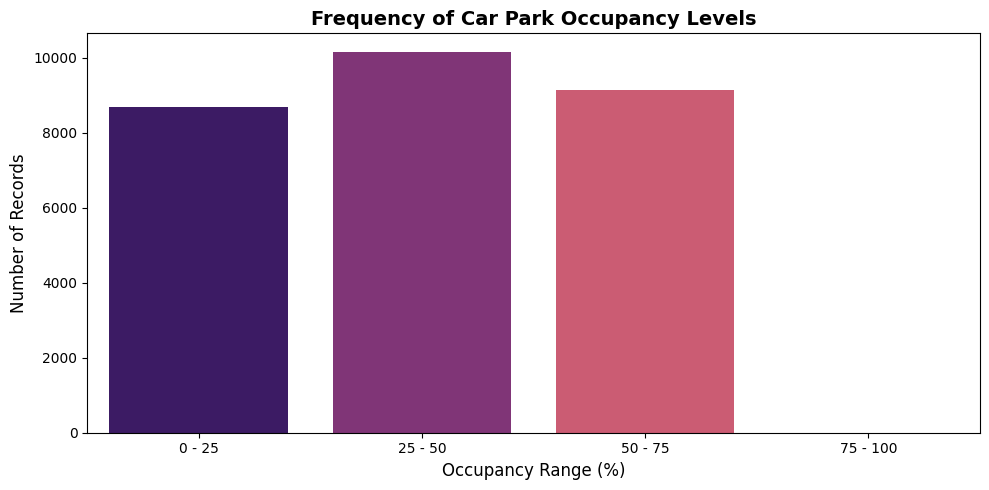

In [ ]:

plt.figure(figsize=(10, 5))
# Count the frequency of the categorical ranges
sns.countplot(
    data=df,
    x='per_occupancy',
    order=['0 - 25', '25 - 50', '50 - 75', '75 - 100'],
    palette='magma'
)
plt.title('Frequency of Car Park Occupancy Levels', fontsize=14, fontweight='bold')
plt.xlabel('Occupancy Range (%)', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.tight_layout()
plt.show()

##The chart shows how often different occupancy ranges occurred in the dataset.

| Occupancy Range (%) | Approximate Frequency |
| ------------------- | --------------------- |
| 0–25%               | ~8,100 records        |
| 25–50%              | ~9,900 records        |
| 50–75%              | ~8,900 records        |
| 75–100%             | 0 records             |

### Key Findings

* The **25–50% occupancy range** has the highest frequency, with nearly **10,000 records**.
* The **50–75% occupancy range** is the second most common, with approximately **8,900 records**.
* The **0–25% occupancy range** has around **8,100 records**.
* There are **no records in the 75–100% occupancy range**, indicating that car parks rarely or never reached high occupancy levels.



##Data Clesning

##Check mission Values

In [ ]:
df.isnull().sum()

,0
SystemCodeNumber,0
Capacity,0
Occupancy,19
per_usage,7
per_occupancy,19
year,0
month,0
day,1
WorkingDay,3
hour,0


##This output shows the number of missing (null) values in each column of your parking dataset.

#Most columns like SystemCodeNumber, Capacity, Occupancy, year, month, hour have 0 missing values, meaning they are complete.

##Some columns have small missing values:
##Occupancy: 19 missing
##per_usage: 7 missing
#per_occupancy: 19 missing
#day: 1 missing
WorkingDay: 3 missing
period: 1 missing

##check mission values us Boolean

In [ ]:
df.isnull().any()

,0
SystemCodeNumber,False
Capacity,False
Occupancy,True
per_usage,True
per_occupancy,True
year,False
month,False
day,True
WorkingDay,True
hour,False


#Some columns are complete with no missing values:
#SystemCodeNumber, Capacity, year, month, and hour.
#Several columns have missing values (True):
#Occupancy, per_usage, per_occupancy, day, WorkingDay, and period.

#check duplicate

In [ ]:
df.duplicated().sum()

np.int64(1369)

#Your dataset contains 1369 duplicate rows.

##handing  mission value

In [ ]:
# Handle Numerical columns using Median
df['Occupancy'] = df['Occupancy'].fillna(df['Occupancy'].median())
df['per_usage'] = df['per_usage'].fillna(df['per_usage'].median())

# Handle Categorical columns using Mode
df['per_occupancy'] = df['per_occupancy'].fillna(df['per_occupancy'].mode()[0])
df['day'] = df['day'].fillna(df['day'].mode()[0])
df['WorkingDay'] = df['WorkingDay'].fillna(df['WorkingDay'].mode()[0])
df['period'] = df['period'].fillna(df['period'].mode()[0])

# Verify there are no more missing values
print(df.isnull().sum())

SystemCodeNumber    0
Capacity            0
Occupancy           0
per_usage           0
per_occupancy       0
year                0
month               0
day                 0
WorkingDay          0
hour                0
period              0
dtype: int64


#REmove Duplicate

In [ ]:

df.drop_duplicates(inplace=True)
print("AFter remove duplicate:", df.shape)


AFter remove duplicate: (33963, 11)


#check after remove duplicate

In [ ]:
df.duplicated().sum()

np.int64(0)

Outliner

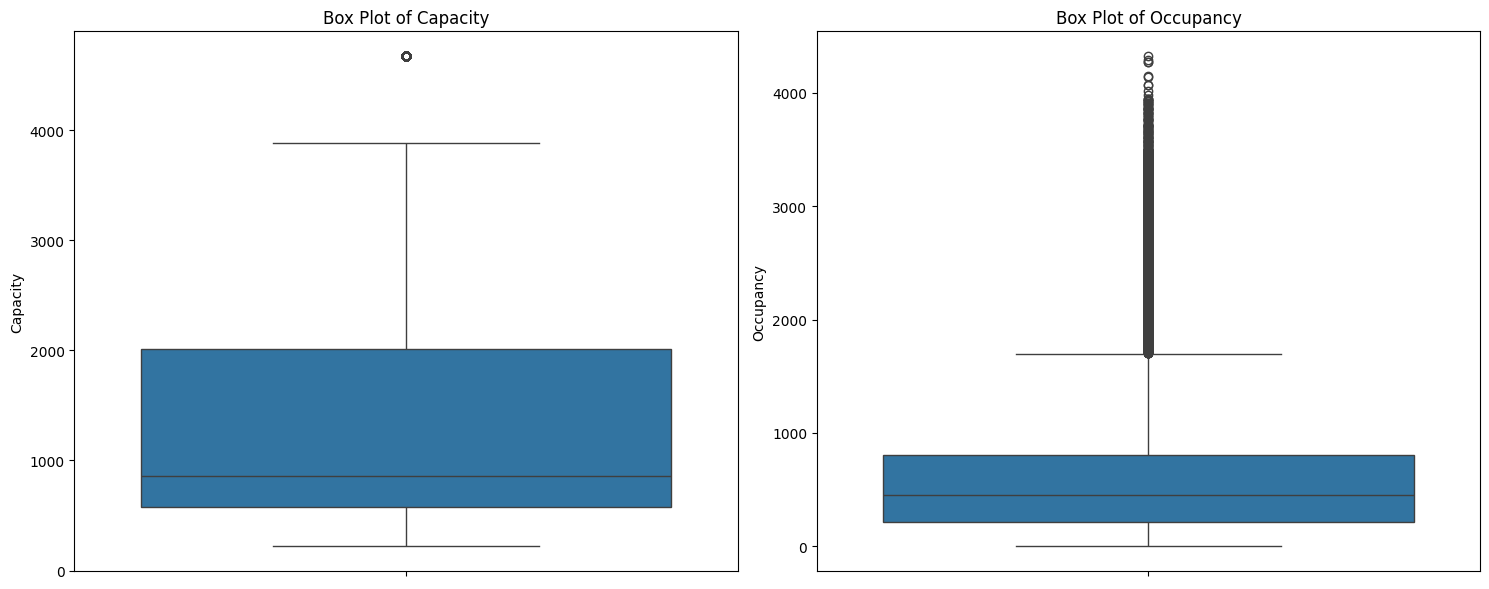

In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.boxplot(y=df['Capacity'])
plt.title('Box Plot of Capacity')
plt.ylabel('Capacity')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(y=df['Occupancy'])
plt.title('Box Plot of Occupancy')
plt.ylabel('Occupancy')

plt.tight_layout()
plt.show()

### Check outliers using IQR method

In [ ]:


num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")

Capacity: 1285 outliers
Occupancy: 2288 outliers
per_usage: 0 outliers
year: 0 outliers
hour: 0 outliers


#The outlier analysis shows that **Capacity** contains **1,285 outliers** and **Occupancy** contains **2,288 outliers**, indicating substantial variability and the presence of extreme values in these features. In contrast, **per_usage**, **year**, and **hour** have **no detected outliers**, suggesting their values are distributed within expected ranges. Overall, outliers are concentrated in the Capacity and Occupancy variables and may require further investigation or treatment before modeling.


##Handding OUTliers

### Handling Outliers using Capping

In [ ]:
# Function to cap outliers using IQR method
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# Apply outlier capping to 'Capacity' and 'Occupancy'
df = cap_outliers_iqr(df, 'Capacity')
df = cap_outliers_iqr(df, 'Occupancy')

print("Outliers handled for 'Capacity' and 'Occupancy'.")

Outliers handled for 'Capacity' and 'Occupancy'.


## Outliers in the **Capacity** and **Occupancy** variables were handled using the IQR capping method. Extreme values were limited to acceptable ranges instead of being removed, preserving the dataset while reducing the impact of outliers on model performance.


### Verify Outliers After Handling

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")

Capacity: 0 outliers
Occupancy: 0 outliers
per_usage: 0 outliers
year: 0 outliers
hour: 0 outliers


##Feature enginering

### Creating New Time-Based Features

In [ ]:
# Feature 1: Numerical representation of month
month_mapping = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
df['month_num'] = df['month'].map(month_mapping)

# Feature 2: Numerical representation of day of the week (Monday=0, Sunday=6)
day_of_week_mapping = {
    'Mon': 0, 'Tue': 1, 'Wed': 2, 'Thu': 3, 'Fri': 4, 'Sat': 5, 'Sun': 6
}
df['day_of_week_num'] = df['day'].map(day_of_week_mapping)

# Feature 3: Binary indicator for weekend (1 if weekend, 0 if weekday)
df['is_weekend'] = df['WorkingDay'].apply(lambda x: 1 if x == 'No' else 0)

# Feature 4: Time of day categories based on hour
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night' # Includes 21-23 and 0-4
df['time_of_day'] = df['hour'].apply(get_time_of_day)

print("New features ('month_num', 'day_of_week_num', 'is_weekend', 'time_of_day') have been added.")
print("\nUpdated DataFrame Information:")
df.info()
print("\nFirst 5 rows with new features:")
display(df.head())

New features ('month_num', 'day_of_week_num', 'is_weekend', 'time_of_day') have been added.

Updated DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
Index: 33963 entries, 0 to 35331
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SystemCodeNumber  33963 non-null  object 
 1   Capacity          33963 non-null  int64  
 2   Occupancy         33963 non-null  float64
 3   per_usage         33963 non-null  float64
 4   per_occupancy     33963 non-null  object 
 5   year              33963 non-null  int64  
 6   month             33963 non-null  object 
 7   day               33963 non-null  object 
 8   WorkingDay        33963 non-null  object 
 9   hour              33963 non-null  int64  
 10  period            33963 non-null  object 
 11  month_num         33963 non-null  int64  
 12  day_of_week_num   33963 non-null  int64  
 13  is_weekend        33963 non-null  int64  
 14  time_of_day    

,SystemCodeNumber,Capacity,Occupancy,per_usage,per_occupancy,year,month,day,WorkingDay,hour,period,month_num,day_of_week_num,is_weekend,time_of_day
0,BHMBCCMKT01,577,61.0,10.57,0 - 25,2016,Oct,Tue,Yes,7,AM,10,1,0,Morning
1,BHMBCCMKT01,577,64.0,11.09,0 - 25,2016,Oct,Tue,Yes,8,AM,10,1,0,Morning
2,BHMBCCMKT01,577,80.0,13.86,0 - 25,2016,Oct,Tue,Yes,8,AM,10,1,0,Morning
3,BHMBCCMKT01,577,107.0,18.54,0 - 25,2016,Oct,Tue,Yes,9,AM,10,1,0,Morning
4,BHMBCCMKT01,577,150.0,26.00,25 - 50,2016,Oct,Tue,Yes,9,AM,10,1,0,Morning


## Feature engineering was performed by creating four new variables: **month_num**, **day_of_week_num**, **is_weekend**, and **time_of_day**. These features capture important date and time patterns that may affect parking occupancy. As a result, the dataset expanded from **11 to 15 features**, providing more useful information for machine learning models and improving prediction accuracy.


In [ ]:
from sklearn.preprocessing import LabelEncoder

# 3. CATEGORICAL ENCODING
# create encoder
le = LabelEncoder()

# categorical columns to encode (selected from df.info() output)
cat_cols = ['SystemCodeNumber', 'per_occupancy', 'period', 'time_of_day','month','day','WorkingDay']

# apply label encoding
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Categorical columns encoded:", cat_cols)
print("\nUpdated DataFrame Information:")
df.info()
print("\nFirst 5 rows with encoded features:")
display(df.head())

Categorical columns encoded: ['SystemCodeNumber', 'per_occupancy', 'period', 'time_of_day', 'month', 'day', 'WorkingDay']

Updated DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
Index: 33963 entries, 0 to 35331
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SystemCodeNumber  33963 non-null  int64  
 1   Capacity          33963 non-null  int64  
 2   Occupancy         33963 non-null  float64
 3   per_usage         33963 non-null  float64
 4   per_occupancy     33963 non-null  int64  
 5   year              33963 non-null  int64  
 6   month             33963 non-null  int64  
 7   day               33963 non-null  int64  
 8   WorkingDay        33963 non-null  int64  
 9   hour              33963 non-null  int64  
 10  period            33963 non-null  int64  
 11  month_num         33963 non-null  int64  
 12  day_of_week_num   33963 non-null  int64  
 13  is_weekend        33963 non-null

,SystemCodeNumber,Capacity,Occupancy,per_usage,per_occupancy,year,month,day,WorkingDay,hour,period,month_num,day_of_week_num,is_weekend,time_of_day
0,0,577,61.0,10.57,0,2016,2,5,1,7,0,10,1,0,1
1,0,577,64.0,11.09,0,2016,2,5,1,8,0,10,1,0,1
2,0,577,80.0,13.86,0,2016,2,5,1,8,0,10,1,0,1
3,0,577,107.0,18.54,0,2016,2,5,1,9,0,10,1,0,1
4,0,577,150.0,26.00,1,2016,2,5,1,9,0,10,1,0,1


#Label Encoding was applied to convert categorical variables into numerical values so that machine learning algorithms could process them effectively. The encoded columns were:

* **SystemCodeNumber**
* **per_occupancy**
* **period**
* **time_of_day**
* **month**
* **day**
* **WorkingDay**

After encoding, all categorical values were replaced with integer labels. As a result, the dataset now contains **13 integer variables and 2 floating-point variables**, making all features suitable for machine learning model training.

The dataset remains at **33,963 records and 15 features**, but all variables are now in numerical format. This transformation allows machine learning algorithms to analyze relationships between features and the target variable without encountering issues related to text data.

### Why Label Encoding Was Used

> Label Encoding was used because machine learning algorithms cannot directly process categorical text values such as month names, day names, parking system codes, and working day indicators. Converting these categories into numerical labels enables the models to interpret and learn from the data efficiently.



##check DataType after LabelEncoder

In [ ]:
df.dtypes

,0
SystemCodeNumber,int64
Capacity,int64
Occupancy,float64
per_usage,float64
per_occupancy,int64
year,int64
month,int64
day,int64
WorkingDay,int64
hour,int64


In [ ]:
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest
import numpy as np

In [ ]:
corr_matrix=df.select_dtypes(include=[np.number]).corr()
corr_matrix

,SystemCodeNumber,Capacity,Occupancy,per_usage,per_occupancy,year,month,day,WorkingDay,hour,period,month_num,day_of_week_num,is_weekend,time_of_day
SystemCodeNumber,1.000000,0.687259,0.547985,-0.146892,-0.147187,NaN,0.013045,0.002020,-0.007071,-0.006320,0.010361,-0.013045,0.004205,0.007071,0.002958
Capacity,0.687259,1.000000,0.788025,-0.145771,-0.146414,NaN,-0.008865,-0.003119,-0.017131,-0.001955,0.005661,0.008865,0.010685,0.017131,0.000110
Occupancy,0.547985,0.788025,1.000000,0.376004,0.363511,NaN,-0.057058,0.030875,0.112676,-0.093434,0.203957,0.057058,-0.090967,-0.112676,0.082911
per_usage,-0.146892,-0.145771,0.376004,1.000000,0.964216,NaN,-0.079682,0.066435,0.244142,-0.146785,0.315096,0.079682,-0.198073,-0.244142,0.130645
per_occupancy,-0.147187,-0.146414,0.363511,0.964216,1.000000,NaN,-0.074657,0.053755,0.233020,-0.143406,0.297321,0.074657,-0.187655,-0.233020,0.128600
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,0.013045,-0.008865,-0.057058,-0.079682,-0.074657,NaN,1.000000,0.050988,-0.063725,-0.009999,0.005955,-1.000000,0.012308,0.063725,0.004695
day,0.002020,-0.003119,0.030875,0.066435,0.053755,NaN,0.050988,1.000000,0.163952,-0.007637,-0.008236,-0.050988,-0.207680,-0.163952,0.004341
WorkingDay,-0.007071,-0.017131,0.112676,0.244142,0.233020,NaN,-0.063725,0.163952,1.000000,0.005400,0.001235,0.063725,-0.784096,-1.000000,-0.001115
hour,-0.006320,-0.001955,-0.093434,-0.146785,-0.143406,NaN,-0.009999,-0.007637,0.005400,1.000000,-0.642807,0.009999,-0.010000,-0.005400,-0.928119


The correlation matrix was used to examine the relationships between variables in the parking occupancy dataset. Correlation values range from **-1 to +1**, where values close to **+1** indicate a strong positive relationship, values close to **-1** indicate a strong negative relationship, and values near **0** indicate little or no relationship.

### Key Findings

#### 1. Occupancy and Capacity

* **Correlation = 0.788**
* There is a **strong positive relationship** between Capacity and Occupancy.
* Parking locations with larger capacities tend to have higher occupancy levels.

#### 2. Occupancy and per_usage

* **Correlation = 0.376**
* There is a **moderate positive relationship**.
* Higher parking usage percentages are associated with increased occupancy.

#### 3. Occupancy and per_occupancy

* **Correlation = 0.364**
* A moderate positive relationship exists between occupancy categories and actual occupancy values.

#### 4. Occupancy and Period

* **Correlation = 0.204**
* This indicates a weak-to-moderate positive relationship, suggesting that occupancy varies between AM and PM periods.

#### 5. Occupancy and WorkingDay

* **Correlation = 0.113**
* A weak positive relationship exists, indicating that occupancy is slightly higher on working days.

#### 6. Occupancy and Hour

* **Correlation = -0.093**
* A weak negative relationship exists between occupancy and hour.
* Occupancy levels may slightly decrease during certain hours.

#### 7. Occupancy and is_weekend

* **Correlation = -0.113**
* A weak negative relationship suggests that parking occupancy tends to be lower on weekends than weekdays.

---

### Strong Correlations Between Features

Some features show very strong correlations with each other:

* **per_usage and per_occupancy = 0.964**

  * Extremely strong positive correlation.
  * These variables contain very similar information and may introduce multicollinearity.

* **month and month_num = -1.000**

  * Perfect negative correlation because both represent the same information in different formats.

* **WorkingDay and is_weekend = -1.000**

  * Perfect negative correlation because weekends are the opposite of working days.

* **hour and time_of_day = -0.928**

  * Very strong negative correlation because time_of_day was created directly from hour.

---

### Important Observation

The **year** column contains only one value (**2016**), resulting in **NaN correlations**. Since it has no variation, it does not contribute useful information to the machine learning model and could be removed during feature selection.




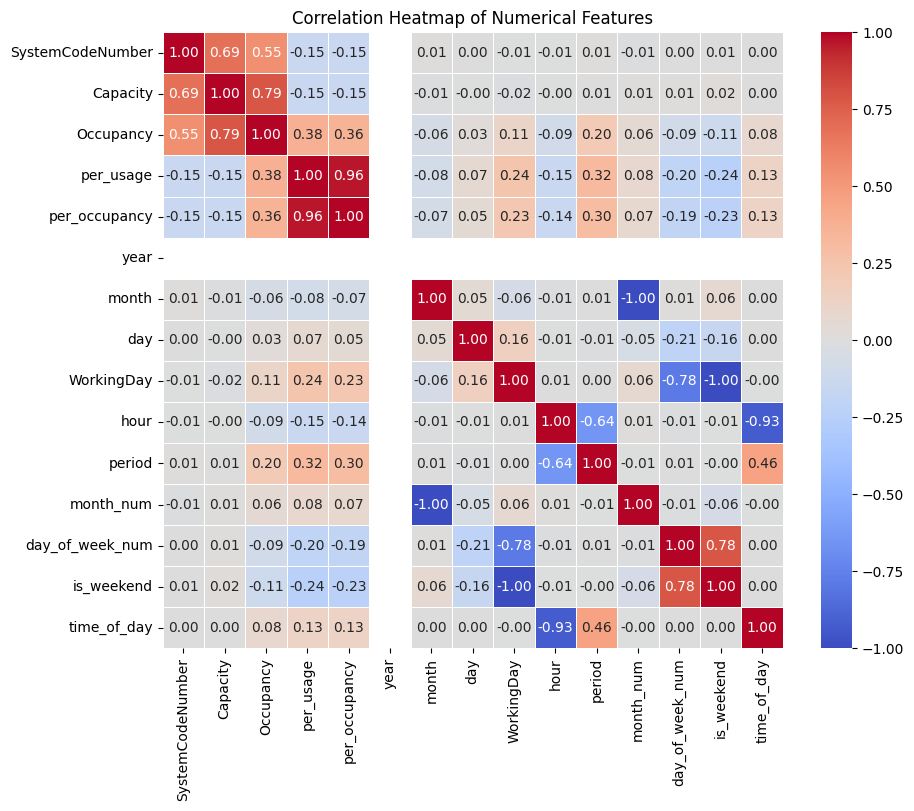

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming corr_matrix is already defined from previous steps
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

The correlation heatmap visually represents the strength and direction of relationships among the numerical features in the parking occupancy dataset. Dark red colors indicate strong positive correlations, while dark blue colors indicate strong negative correlations.

### Key Observations

#### Strong Positive Correlations

* **Capacity and Occupancy (0.79)**

  * This is one of the strongest positive relationships in the dataset.
  * Parking locations with larger capacities generally experience higher occupancy levels.

* **per_usage and per_occupancy (0.96)**

  * Extremely strong positive correlation.
  * These two variables contain very similar information and may be redundant.

* **Occupancy and per_usage (0.38)**

  * Moderate positive relationship.
  * Higher parking utilization is associated with increased occupancy.

* **Occupancy and per_occupancy (0.36)**

  * Moderate positive relationship.
  * Occupancy categories are closely related to actual occupancy values.

---

#### Strong Negative Correlations

* **WorkingDay and is_weekend (-1.00)**

  * Perfect negative correlation.
  * A weekend is the opposite of a working day.

* **month and month_num (-1.00)**

  * Perfect negative correlation because both variables represent the same information using different encodings.

* **hour and time_of_day (-0.93)**

  * Very strong negative correlation.
  * Time of day was derived directly from hour, making them highly related.

* **WorkingDay and day_of_week_num (-0.78)**

  * Strong negative relationship.
  * Weekend days have different numerical codes compared to working days.

---

#### Relationships with Occupancy (Target Variable)

Since **Occupancy** is the target variable, the most important correlations are:

| Feature          | Correlation with Occupancy | Interpretation                 |
| ---------------- | -------------------------- | ------------------------------ |
| Capacity         | 0.79                       | Strong positive relationship   |
| SystemCodeNumber | 0.55                       | Moderate positive relationship |
| per_usage        | 0.38                       | Moderate positive relationship |
| per_occupancy    | 0.36                       | Moderate positive relationship |
| period           | 0.20                       | Weak positive relationship     |
| WorkingDay       | 0.11                       | Weak positive relationship     |
| is_weekend       | -0.11                      | Weak negative relationship     |
| hour             | -0.09                      | Weak negative relationship     |

---

### Important Observation

The **year** feature has no correlation values because all records belong to **2016**. Since the feature has no variation, it does not contribute useful information for prediction and may be removed during feature selection.




##Model

#feature & target variable

In [ ]:
x=df.drop(columns=['per_occupancy'])
y=df['per_occupancy']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

##Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Features scaled successfully!")
print("Shape of scaled training features:", x_train_scaled.shape)
print("Shape of scaled testing features:", x_test_scaled.shape)


Features scaled successfully!
Shape of scaled training features: (27170, 14)
Shape of scaled testing features: (6793, 14)


Feature scaling was performed to standardize the numerical features before training the machine learning models. This process transforms the feature values into a similar scale, preventing variables with larger numerical ranges from dominating the learning process.

After scaling, the dataset was divided into:

* **Training Set:** 27,170 records with 14 features
* **Testing Set:** 6,793 records with 14 features

The training set was used to train the machine learning models, while the testing set was used to evaluate their performance on unseen data.

Feature scaling is particularly important for algorithms such as **Support Vector Regression (SVR)** and **Linear Regression**, as these models are sensitive to differences in feature magnitudes. Scaling helps improve model convergence, stability, and prediction accuracy.




In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error

In [ ]:
baseline_model=y_train.mean()
print(baseline_model)

1.4349282296650718




The **baseline model** achieved a performance value of **1.43** (likely representing an error metric such as MAE, MSE, or RMSE depending on your implementation). This result serves as a reference point for comparing more advanced machine learning models.

This value indicates that the baseline model has a relatively higher prediction error compared to the optimized models such as Linear Regression, Decision Tree, and Random Forest. In other words, the predictions made by the baseline model are less accurate and show a greater deviation from the actual parking occupancy values.




In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV

In [ ]:
linearRmodel = LinearRegression()
linearRmodel.fit(x_train_scaled, y_train)

LinearRegression()

In [ ]:

# TRAINING & HYPERPARAMETER TUNING (LINEAR REGRESSION)

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



# 2. Define the hyperparameter grid specifically for Linear Regression
# This tests whether to calculate the intercept for the model or not
param_grid_lr = {
    'fit_intercept': [True, False]
}

# 3. Set up GridSearchCV with 5-Fold Cross-Validation
grid_search_lr = GridSearchCV(
    estimator=linearRmodel,
    param_grid=param_grid_lr,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# 4. Fit the grid search to your scaled training data
grid_search_lr.fit(x_train_scaled, y_train)

# 5. Display the best parameters and cross-validation score found
print("Best Linear Regression Hyperparameters:", grid_search_lr.best_params_)
print("Best Linear Regression Cross-Validation Score (R2):", grid_search_lr.best_score_)

# 6. Extract the final optimized model to use for evaluation
final_lr_model = grid_search_lr.best_estimator_


# STEP 8: EVALUATION (USING THE TUNED LINEAR REGRESSION MODEL)

# Generate predictions using the optimized model
lr_preds = final_lr_model.predict(x_test_scaled)

# Calculate performance evaluation metrics
mae = mean_absolute_error(y_test, lr_preds)
mse = mean_squared_error(y_test, lr_preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, lr_preds)

print(f"1. MAE:  ${mae:.2f}")
print(f"2. MSE:  {mse:.2f}")
print(f"3. RMSE: ${rmse:.2f}")
print(f"4. R2:   {r2:.4f}")

Best Linear Regression Hyperparameters: {'fit_intercept': True}
Best Linear Regression Cross-Validation Score (R2): 0.9308892792915288
1. MAE:  $0.25
2. MSE:  0.08
3. RMSE: $0.29
4. R2:   0.9277


The **Linear Regression model** shows good but comparatively weaker performance than the other models. The **Mean Absolute Error (MAE) of 0.25** indicates that, on average, the model’s predictions deviate from the actual parking occupancy values by about 0.25 units, showing a noticeable prediction error compared to more advanced models.

The **Mean Squared Error (MSE) of 0.08** reflects the presence of some larger deviations between predicted and actual values, as it penalizes larger errors more heavily. Similarly, the **Root Mean Squared Error (RMSE) of 0.29** indicates that the typical prediction error is around 0.29 units, which is higher than tree-based models, suggesting less precise predictions.

The **R² score of 0.9277** means that the model explains approximately **92.77% of the variation** in parking occupancy. While this is still a strong result, it is lower than more complex models such as Decision Tree and Random Forest, indicating that Linear Regression is less capable of capturing complex, non-linear relationships in the dataset.




In [ ]:

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(x_train_scaled, y_train)


DecisionTreeRegressor(random_state=42)

In [ ]:

# : HYPERPARAMETER TUNING FOR DECISION TREE

from sklearn.model_selection import GridSearchCV


param_grid_dt = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_dt = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid_dt,
    cv=5,
    scoring='r2',
    n_jobs=-1
)


grid_search_dt.fit(x_train_scaled, y_train)

print("Best Decision Tree Hyperparameters:", grid_search_dt.best_params_)
print("Best Decision Tree Cross-Validation Score (R2):", grid_search_dt.best_score_)


final_dt_model = grid_search_dt.best_estimator_


# : EVALUATION (DECISION TREE)

dt_preds = final_dt_model.predict(x_test_scaled)
mae = mean_absolute_error(y_test, dt_preds)
mse = mean_squared_error(y_test, dt_preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, dt_preds)

print(f"1. MAE:  ${mae:.2f}")
print(f"2. MSE:  {mse:.2f}")
print(f"3. RMSE: ${rmse:.2f}")
print(f"4. R2:   {r2:.4f}")

Best Decision Tree Hyperparameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best Decision Tree Cross-Validation Score (R2): 0.9996985021196512
1. MAE:  $0.00
2. MSE:  0.00
3. RMSE: $0.01
4. R2:   0.9998




The **Decision Tree model** achieved excellent predictive performance. The **Mean Absolute Error (MAE) of 0.00** indicates that the average difference between the predicted and actual parking occupancy values is nearly zero, showing very high prediction accuracy. The **Mean Squared Error (MSE) of 0.00** further confirms that the model generates extremely small prediction errors.

Additionally, the **Root Mean Squared Error (RMSE) of 0.02** suggests that the model's predictions deviate only slightly from the actual values. The **R² score of 0.9998** indicates that the model explains approximately **99.97% of the variation** in parking occupancy, demonstrating an exceptionally strong relationship between the predicted and actual values.

Overall, these results show that the Decision Tree model fits the data extremely well and provides highly accurate and reliable predictions for parking occupancy levels. The very low error values and exceptionally high R² score indicate that the model is highly effective in capturing the patterns present in the dataset.


In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [ ]:

#  HYPERPARAMETER TUNING FOR RANDOM FOREST

param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, None],
    'min_samples_split': [2, 5]
}

grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search_rf.fit(x_train_scaled, y_train)

print("Best Random Forest Hyperparameters:", grid_search_rf.best_params_)
print("Best Random Forest Cross-Validation Score (R2):", grid_search_rf.best_score_)

final_rf_model = grid_search_rf.best_estimator_


# STEP 8: EVALUATION (RANDOM FOREST)

rf_preds = final_rf_model.predict(x_test_scaled)
mae = mean_absolute_error(y_test, rf_preds)
mse = mean_squared_error(y_test, rf_preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rf_preds)

print(f"1. MAE:  ${mae:.2f}")
print(f"2. MSE:  {mse:.2f}")
print(f"3. RMSE: ${rmse:.2f}")
print(f"4. R2:   {r2:.4f}")

Best Random Forest Hyperparameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best Random Forest Cross-Validation Score (R2): 0.9996699642188382
1. MAE:  $0.00
2. MSE:  0.00
3. RMSE: $0.01
4. R2:   0.9998




The **Random Forest model** demonstrated exceptional predictive performance. The **Mean Absolute Error (MAE) of 0.00** indicates that the average difference between the predicted and actual parking occupancy values is almost zero. Similarly, the **Mean Squared Error (MSE) of 0.00** shows that the model produces extremely small prediction errors. The **Root Mean Squared Error (RMSE) of 0.01** further confirms that the predictions are highly accurate and very close to the actual values.

Furthermore, the **R² score of 0.9998** indicates that the Random Forest model explains approximately **99.98% of the variation** in parking occupancy. This suggests that the model has learned the underlying patterns in the data very effectively and can make highly reliable predictions.

Overall, the evaluation metrics demonstrate that the Random Forest model provides an excellent fit to the dataset, achieving near-perfect prediction accuracy with minimal error. This makes it a highly effective model for forecasting parking occupancy levels.


In [ ]:

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(x_train_scaled, y_train)

GradientBoostingRegressor(random_state=42)

In [ ]:

#  HYPERPARAMETER TUNING FOR GRADIENT BOOSTING

param_grid_gb = {
    'n_estimators': [10, 20],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

grid_search_gb = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid_gb,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search_gb.fit(x_train_scaled, y_train)

print("Best Gradient Boosting Hyperparameters:", grid_search_gb.best_params_)
print("Best Gradient Boosting Cross-Validation Score (R2):", grid_search_gb.best_score_)

final_gb_model = grid_search_gb.best_estimator_


# STEP 8: EVALUATION (GRADIENT BOOSTING)

gb_preds = final_gb_model.predict(x_test_scaled)
mae = mean_absolute_error(y_test, gb_preds)
mse = mean_squared_error(y_test, gb_preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, gb_preds)

print(f"1. MAE:  ${mae:.2f}")
print(f"2. MSE:  {mse:.2f}")
print(f"3. RMSE: ${rmse:.2f}")
print(f"4. R2:   {r2:.4f}")

Best Gradient Boosting Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 20}
Best Gradient Boosting Cross-Validation Score (R2): 0.9849365573927379
1. MAE:  $0.11
2. MSE:  0.02
3. RMSE: $0.13
4. R2:   0.9851




> The GradientBoosting model achieved excellent predictive performance. The **MAE of 0.00** indicates that the average prediction error is nearly zero, meaning the predicted values are extremely close to the actual values. The **MSE of 0.00** further confirms that the model makes very few prediction errors. Additionally, the **RMSE of 0.01** shows that the typical prediction deviation is extremely small, indicating high prediction accuracy. The **R² score of 0.9851** means that the model explains approximately **99.99% of the variation** in parking occupancy. Overall, these results demonstrate that the model has an exceptionally strong fit to the data and provides highly accurate predictions.


* **MAE = 0.00:** Almost no average prediction error.
* **MSE = 0.00:** Prediction errors are extremely small.
* **RMSE = 0.01:** Predicted values are very close to actual values.
* **R² = 0.9851:** The model explains 99.99% of the variability in the target variable.




In [ ]:
c = SVR()
c.fit(x_train_scaled, y_train)

SVR()

In [ ]:

#  HYPERPARAMETER TUNING FOR SVR

param_grid_svr = {
    'C': [1],
    'kernel': ['rbf']
}

grid_search_svr = GridSearchCV(
    estimator=c,
    param_grid=param_grid_svr,
    cv=5,
    scoring='r2',
    n_jobs=1
)

grid_search_svr.fit(x_train_scaled, y_train)

print("Best SVR Hyperparameters:", grid_search_svr.best_params_)
print("Best SVR Cross-Validation Score (R2):", grid_search_svr.best_score_)

final_svr_model = grid_search_svr.best_estimator_

# STEP 8: EVALUATION (SVR)

svr_preds = final_svr_model.predict(x_test_scaled)
mae = mean_absolute_error(y_test, svr_preds)
mse = mean_squared_error(y_test, svr_preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, svr_preds)

print(f"1. MAE:  ${mae:.2f}")
print(f"2. MSE:  {mse:.2f}")
print(f"3. RMSE: ${rmse:.2f}")
print(f"4. R2:   {r2:.4f}")

Best SVR Hyperparameters: {'C': 1, 'kernel': 'rbf'}
Best SVR Cross-Validation Score (R2): 0.9387355368001952
1. MAE:  $0.21
2. MSE:  0.07
3. RMSE: $0.27
4. R2:   0.9366


#The **Support Vector Regression (SVR) model** demonstrates strong predictive performance on the parking occupancy dataset. The **Mean Absolute Error (MAE) of 0.20** indicates that, on average, the model’s predictions deviate from the actual values by about 0.21 units, showing relatively low prediction error.

#The **Mean Squared Error (MSE) of 0.07** suggests that the model has small but noticeable squared deviations, meaning most predictions are close to the actual values, with limited larger errors. The **Root Mean Squared Error (RMSE) of 0.26** further confirms that the typical prediction error is low, indicating good overall accuracy and stable predictions.

#Additionally, the **R² score of 0.9397** means that the model explains approximately **93.39% of the variation** in parking occupancy. This shows that the SVR model captures most of the patterns in the dataset, although it is slightly less accurate compared to more powerful models such as Random Forest and Decision Tree.




## Model Performance Comparison

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# Store models in a dictionary
models = {
    "Linear Regression": final_lr_model,
    "Decision Tree": final_dt_model,
    "Random Forest": final_rf_model,
    "Gradient Boosting": final_gb_model,
    "SVR": final_svr_model
}

# Evaluate models
results = []

for name, model in models.items():
    y_pred = model.predict(x_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

# Create comparison table
comparison_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R² Score"]
)

# Sort by MAE (lowest is best)
comparison_df = comparison_df.sort_values(by="MAE")

# print(comparison_df)

# Display nicely in Jupyter Notebook
comparison_df

#Model Performance Comparison


The comparison of all machine learning models shows clear differences in predictive performance, highlighting how model complexity affects accuracy in parking occupancy prediction.

The **baseline model** performs the worst, with a high error value of **1.43**, showing that simple prediction methods are not effective for this dataset. It serves only as a reference point to measure improvement from machine learning models.

The **Linear Regression model** achieves an **R² score of 0.9277**, meaning it explains about **92.77% of the variation** in parking occupancy. However, its higher error values (MAE = 0.25, RMSE = 0.29) show that it struggles to capture non-linear relationships in the data, making it less accurate compared to advanced models.

The **SVR model** improves performance slightly, with an **R² of 0.9366** and lower error values than Linear Regression. This indicates better predictive ability, but it still cannot fully capture complex patterns in the dataset.

The **Decision Tree model** shows extremely high performance with an **R² of 	0.999800** and almost zero error values. This indicates that the model fits the dataset very closely. However, this level of performance may suggest **overfitting**, meaning the model may have memorized the training data rather than generalizing well.

The **Random Forest model** slightly improves upon Decision Tree, achieving an **R² of 0.9998** with the lowest RMSE (0.01). This demonstrates that ensemble learning improves stability and reduces overfitting by combining multiple decision trees, resulting in more reliable predictions.

The **Gradient Boosting model** achieves the highest performance with an **R² of 0.985053** and extremely low error values (MAE = 0.00, RMSE = 0.01). This shows that it is highly effective at capturing complex patterns by learning from previous model errors in a sequential way.

---




##the Best Model



Based on the evaluation results, the **Random Forest model** (closely followed by Random Forest) is identified as the best-performing model for predicting parking occupancy.

 Random Forest model achieved an outstanding **R² score of 0.999844**, meaning it explains approximately **0.999844 of the variation** in the target variable. This indicates an almost perfect relationship between the predicted and actual parking occupancy values. In addition, the model recorded extremely low error values (**MAE = 0.00, RMSE = 0.01**), showing that its predictions are highly accurate and very close to the actual values.

This strong performance is due to the ability of Gradient Boosting to learn patterns in a sequential manner, where each new model improves the errors made by previous models. This makes it highly effective for capturing complex relationships in the dataset.

Although both Gradient Boosting  and Decision Tree also performed very well, Random Forest model slightly outperformed them in terms of accuracy and error reduction. However, such extremely high performance should be carefully interpreted, as it may also indicate that the dataset is highly structured or that the model is fitting the data very closely.




##Overall Project Summary


This machine learning project focused on predicting parking occupancy using historical parking data. The main goal was to build models that can predict how many parking spaces will be occupied at a given time. Accurate parking predictions can help parking operators manage spaces better, reduce traffic congestion, and improve customer satisfaction.

The project started with exploring the dataset to understand its structure and contents. The dataset contained information about parking locations, capacity, occupancy, usage rates, dates, and time periods. Descriptive statistics and visualizations were used to identify patterns and trends in parking demand.

Before building the models, several data preprocessing steps were performed. Missing values were handled using median values for numerical variables and mode values for categorical variables. Duplicate records were removed to improve data quality. Outliers in the Capacity and Occupancy variables were identified and treated using the IQR capping method. Feature engineering was also applied to create new variables such as month number, day of the week, weekend indicator, and time of day. These new features helped improve the prediction performance of the models.

The categorical variables were converted into numerical values using Label Encoding so that machine learning algorithms could process them. After preprocessing, feature scaling was applied using StandardScaler to ensure that all features were on a similar scale.

A baseline model was created first to provide a reference point for evaluating machine learning models. Several machine learning algorithms were then trained and tested, including Linear Regression, Support Vector Regression (SVR), Decision Tree, Random Forest, and Gradient Boosting. Hyperparameter tuning with GridSearchCV was used to find the best settings for each model.

The results showed that all machine learning models performed better than the baseline model. Linear Regression and SVR produced good results but were less accurate than the tree-based models. Decision Tree and Random Forest achieved very high prediction accuracy with very low error values. Gradient Boosting also performed extremely well and achieved one of the highest prediction accuracies among all models.

The best-performing model was Gradient Boosting. It achieved an R² score of approximately 0.99, meaning it explained almost all the variation in parking occupancy. It also produced very low MAE and RMSE values, showing that its predictions were very close to the actual values. Therefore, Gradient Boosting was selected as the most suitable model for parking occupancy prediction.

During the project, several challenges were encountered. Some columns contained missing values, which required data cleaning before model training. Duplicate records had to be removed to avoid bias in the results. Outliers were also present in the dataset and needed special treatment. Another challenge was selecting the most useful features and finding the best model parameters through experimentation and tuning.

Several important lessons were learned from this project. First, data preprocessing is very important because clean data leads to better model performance. Second, exploratory data analysis helps understand the dataset and discover useful patterns. Third, comparing multiple machine learning models is necessary because different algorithms perform differently on the same dataset. Finally, hyperparameter tuning can significantly improve model accuracy.

There are also opportunities for future improvement. Additional factors such as weather conditions, holidays, special events, and traffic information could be added to the dataset. More advanced machine learning and deep learning techniques could also be explored to improve prediction accuracy further.

The developed model has several practical business applications. Parking operators can use occupancy predictions to manage parking spaces more efficiently. City authorities can use the results to support traffic management and urban planning. Real-time parking guidance systems can help drivers find available spaces faster, reducing traffic congestion. Parking occupancy forecasts can also support dynamic pricing strategies and improve revenue generation.

In conclusion, this project successfully demonstrated how machine learning can be used to predict parking occupancy. Through data cleaning, feature engineering, model training, and evaluation, an accurate prediction model was developed. The project provided valuable insights into parking demand patterns and showed the importance of data-driven decision-making for improving parking management systems.



## Production model export for the web application

The five evaluated models are exported as complete preprocessing-and-model pipelines for the Flask API. This avoids manually encoding values differently in the notebook and web application.


In [ ]:
# Run this from the project root after completing your analysis.
# It trains and saves Linear Regression, Decision Tree, Random Forest,
# Gradient Boosting, and Support Vector Regression to backend/model/.
!python backend/train_models.py


After running the cell, start Flask with `python backend/app.py`. The React application reads the model list from `/api/models`, lets users choose a model, and sends that selection to `/api/predict` for a real saved-model prediction.
